In [1]:
# Imports
import json

import numpy as np
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import pandas as pd
import xarray as xr
import rioxarray
import pyproj

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from metpy.plots import USCOUNTIES, USSTATES


# Find the repo root and add it to sys.path FIRST
repo = Path.cwd()
while not (repo / "functions").exists() and repo.parent != repo:
    repo = repo.parent
sys.path[:0] = [str(repo), str(Path.cwd().parent.parent)]
from functions.plot_hillshade import *

In [2]:
lcc_tiff_path = "/Users/kylabazlen/Documents/Climate_Roadmap/clim_data_lcc/TX95p/TX95p_GWL25C_actual_values_lcc.tif"

In [3]:
crs_plot = ccrs.Projection(pyproj.CRS(3857))
def create_reference_plot_from_rioxarray(rda, title=None, cmap="viridis", vmin=None, vmax=None):
    """Simple plotting helper for a rioxarray DataArray/RASTER.
    Ignores any external symbology and uses a viridis colormap by default.
    Returns the matplotlib Figure object."""
    # Get data crs
    crs_data = ccrs.Projection(rda.rio.crs)

    # Create figure on plotting crs
    fig, ax_main = plt.subplots(1, 1, figsize=(12,8), subplot_kw=dict(projection=crs_plot))

    # Plot pcolormesh with transform
    pcm = ax_main.pcolormesh(
        rda.x.data, rda.y.data, rda.squeeze().data,
        transform=crs_data, cmap=cmap, vmin=vmin, vmax=vmax
    )

    # Figure decorations
    ax_main.set_extent([250.7, 258.2, 36.7, 41.2], ccrs.Geodetic())
    try:
        ax_main.add_feature(USCOUNTIES.with_scale('5m'), linewidth=0.5, alpha=0.5)
        ax_main.add_feature(USSTATES.with_scale('5m'), linewidth=1.0)
    except Exception:
        pass
    if title is not None:
        ax_main.set_title(title, fontsize=14)
    fig.colorbar(pcm, ax=ax_main, orientation="vertical", shrink=0.7)

    return fig

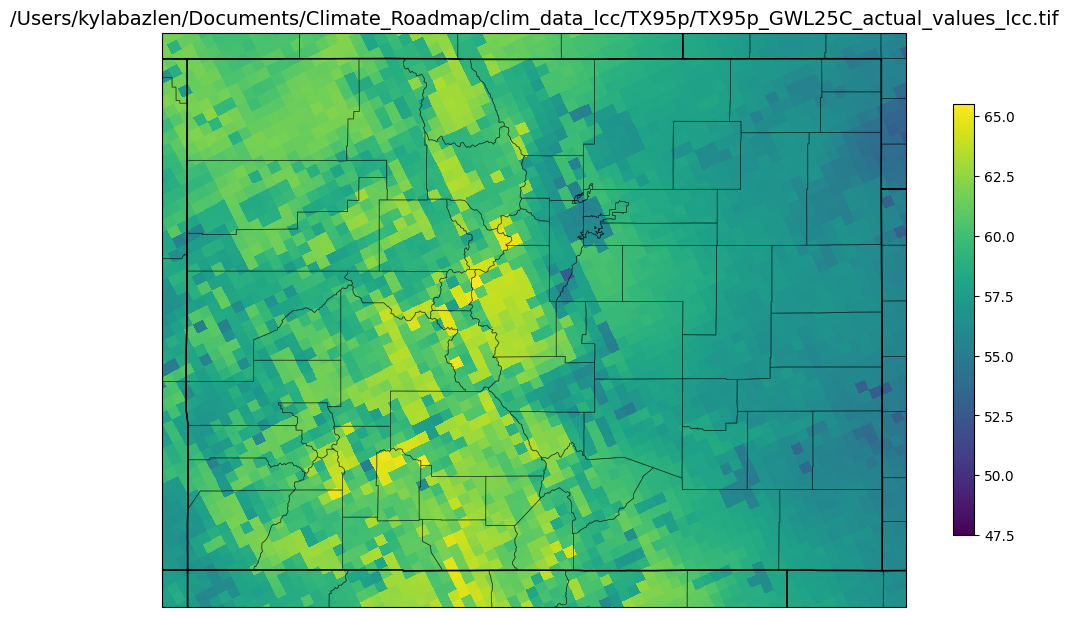

In [4]:
# Open and plot the LCC TIFF with a viridis colormap
rda = rioxarray.open_rasterio(lcc_tiff_path)
create_reference_plot_from_rioxarray(rda, title=lcc_tiff_path)
plt.show()

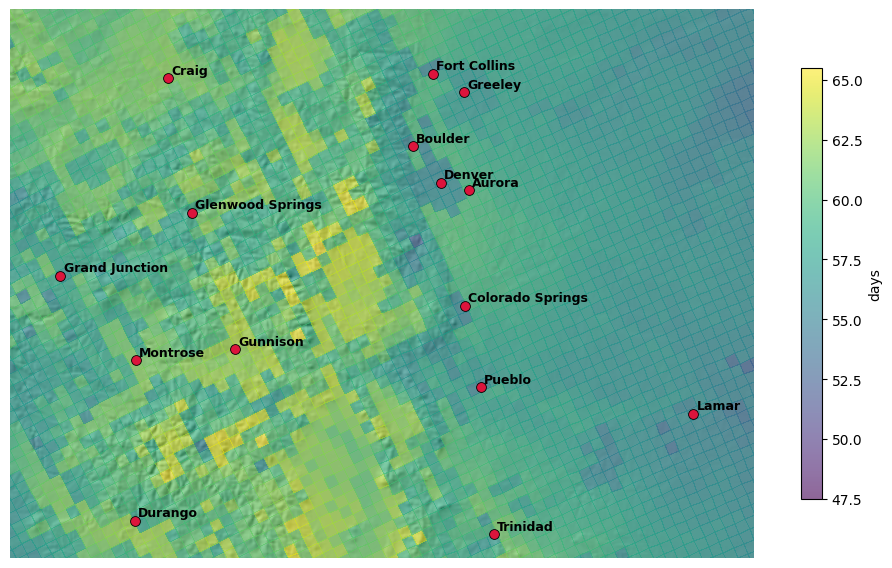

In [8]:
import pyproj
import cartopy.crs as ccrs
import rioxarray

# Open the raster, keep it in its native LCC
rda = rioxarray.open_rasterio(lcc_tiff_path).squeeze()
# rda = rda.coarsen(x=4, y=4, boundary='trim').mean()  # optional downsample

# Build a cartopy CRS from the raster's actual CRS (whatever LCC params it has)
src_crs = ccrs.Projection(pyproj.CRS.from_user_input(rda.rio.crs))

# Display CRS stays Web Mercator
crs_plot = ccrs.Projection(pyproj.CRS(3857))
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=crs_plot)

fig, ax = plot_hillshade(
    shp_path=str(DATA_DIR / "cities_of_interest.shp"),
    nc_path=str(DATA_DIR / "COtopography.nc"),
    elev_var="HGT",
    target_crs="EPSG:3857",
    method="hillshade",
    figsize=(12, 8),
    ax=ax,
)

# Overlay using the raster's native coords + native CRS as transform
pcm = ax.pcolormesh(
    rda.x.data, rda.y.data, rda.data,
    transform=src_crs,        # <-- native LCC, not crs_plot
    cmap="viridis", alpha=0.6,
    edgecolor='none',
    antialiased=False,
)

fig.colorbar(pcm, ax=ax, orientation="vertical", shrink=0.7,
             label=getattr(rda, "units", None))
plt.show()